In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [42]:
df = pd.read_csv('../zuu crew scores.csv')
df = df[df['CourseName']=='Foundations of ML']
del df['MemberName'], df['CourseName']
df.head()

,EducationLevel,Attendance,TotalHours,AssignmentsCompleted,HackathonParticipation,GitHubScore,PeerReviewScore,CapstoneScore
0,3,79.9,43.7,2,0,62.8,5.0,45.3
1,2,76.8,95.6,6,0,87.4,2.7,78.8
2,3,96.6,75.9,8,0,98.4,2.8,65.4
4,2,83.2,24.0,6,0,41.8,4.2,40.1
7,3,86.5,88.0,5,0,23.9,1.3,68.2


In [43]:
Y = df['CapstoneScore'].values
X_df = df.drop(columns=['CapstoneScore'])

mean = X_df.mean()
std = X_df.std()

X_standardized = (X_df - mean) / std

X = X_standardized.values

In [44]:
X = np.column_stack((
    np.ones(len(df)),
    X
))

In [45]:
def compute_cost(X,Y,beta):
    y_hat = X.dot(beta) 
    m = len(Y)
    cost = (1 /(2 * m)) * np.sum((y_hat - Y)**2)
    return cost

In [46]:
cost_history=[]
def gradient_descent(X,Y,beta,n_iter,lr):
    m = len(Y)

    for i in range(n_iter):
        y_hat = X.dot(beta) 
        gradient = (1/m) * X.T.dot(y_hat - Y)
        beta = beta - lr * gradient
        cost  = compute_cost(X,Y,beta)
        cost_history.append(cost)

        if i % 100 == 0:
            print(f"iteration: {i}, cost:{cost}, beta:{beta}")
    
    return beta

In [47]:
beta = np.random.randn(8)
lr = 0.01
n_iter = 1000

In [48]:
beta = gradient_descent(X,Y,beta,n_iter,lr)

iteration: 0, cost:1652.5567457437082, beta:[ 0.01238706  0.82624276  1.19500576  0.61574019  0.70178201 -0.6754176
 -0.85364841 -0.56367056]
iteration: 100, cost:231.27461120013928, beta:[34.94143513 -0.14740337  0.93484795 10.26230709  1.26599507 -0.96594341
  0.36930484  0.86220195]
iteration: 200, cost:40.70170614872704, beta:[47.72659637 -0.27007786  0.81768029 13.82790292  0.80649522 -0.55114978
  0.64074427  1.42474322]
iteration: 300, cost:14.677445307751933, beta:[52.40637887 -0.27824005  0.76936054 15.22265136  0.38413616 -0.19127427
  0.74885806  1.60088814]
iteration: 400, cost:11.037919054152628, beta:[ 5.41193306e+01 -2.87910158e-01  7.52128701e-01  1.57938339e+01
  1.17338045e-01  3.63079965e-02  8.21917134e-01  1.63946660e+00]
iteration: 500, cost:10.507432638973473, beta:[ 5.47463264e+01 -3.03749361e-01  7.47277658e-01  1.60365898e+01
 -3.52311801e-02  1.68098550e-01  8.75735555e-01  1.63837631e+00]
iteration: 600, cost:10.424113145512365, beta:[54.97582707 -0.31938716

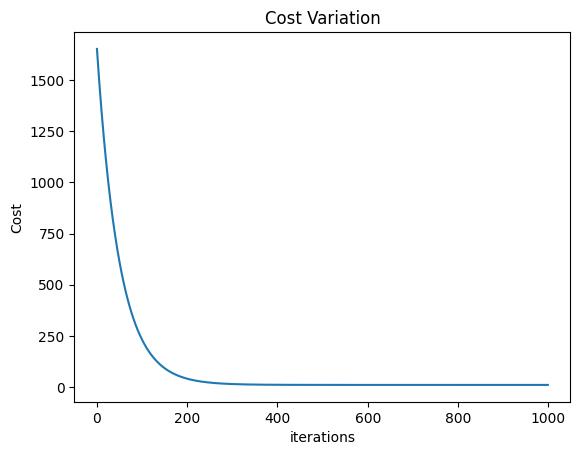

In [49]:
plt.plot(cost_history)
plt.title("Cost Variation")
plt.xlabel("iterations")
plt.ylabel("Cost")
plt.show()

In [50]:
Y_hat = X.dot(beta) 
Y_hat

array([49.96657689, 79.29142832, 68.48056893, 36.56953473, 71.05994082,
       82.29934104, 38.24495568, 56.22444064, 48.82341495, 45.5760795 ,
       59.9627285 , 36.71381768, 39.52455918, 49.96636052, 56.82345105,
       30.84001577, 83.74169282, 28.99996243, 52.49215017, 75.82858363,
       64.94860774, 42.13316332, 34.63707168, 79.92197639, 79.33368745,
       36.87587413, 44.72301752, 43.11685659, 49.58395774, 38.6761097 ,
       78.49829457, 39.95973865, 28.17593325, 61.44201674, 65.93457047,
       68.15009734, 29.38488014, 42.32887255, 32.58484011, 61.16254084,
       62.67582008, 70.36401048, 56.33532417, 70.2912325 , 54.57753605,
       57.15101842, 51.8847166 , 32.89945261, 59.57739913, 43.66542574,
       77.67799758, 39.4718856 , 50.90400347, 76.60805977, 60.5605444 ,
       78.90226702, 75.19730545, 58.44708745, 70.87843498, 72.62521555,
       26.90196872, 51.80008935, 47.81718121, 79.69207272, 44.56779363,
       56.54592196, 67.40780948, 47.80107205, 82.44140173, 42.93

In [51]:
def MSE(Y,Y_hat):
    e_i = Y - Y_hat
    return np.mean(e_i**2)

def MAE(Y,Y_hat):
    e_i = Y - Y_hat
    return np.mean(np.abs(e_i))

def R2_Score(Y,Y_hat):
    y_mean = np.mean(Y)
    e_i = Y - Y_hat
    std_i = Y - y_mean

    E = np.sum(e_i**2) / np.sum(std_i ** 2)
    return 1 - E

def RMSE(Y,Y_hat):
    e_i = Y - Y_hat
    return np.sqrt(np.mean((Y - Y_hat) ** 2))

In [52]:
mse = MSE(Y, Y_hat)
mae = MAE(Y, Y_hat)
r2 = R2_Score(Y, Y_hat)
rmse = RMSE(Y,Y_hat)

print(f"MSE : {mse}")
print(f"MAE : {mae}")
print(f"R2 Score : {r2}")
print(f"RMSE : {rmse}")

MSE : 20.8106008973137
MAE : 3.5381508884687762
R2 Score : 0.9271666017527503
RMSE : 4.561863752603063
